# Saptamana 12 - P1: Explorare ZuCo 1.0
**Task 1 - Citire recenzii de filme (Sentiment Reading)**  
18 subiecti, 105 canale, 500 Hz  
Scop: analiza ERP + PSD per tip de cuvant (substantive, verbe, adjective, cuvinte functionale)

## Sectiunea 1 - Incarcare si inspectie date
Fisierele .mat sunt in format MATLAB v5, le citim cu scipy.io.loadmat.  
Fiecare fisier = un subiect, epoci EEG la nivel de cuvant, aliniate la momentul aparitiei cuvantului.

In [1]:
import scipy.io as sio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mne
import nltk
from scipy import signal
from pathlib import Path
from collections import Counter
import warnings
warnings.filterwarnings('ignore')
mne.set_log_level('WARNING')
%matplotlib inline
plt.rcParams['figure.dpi'] = 100

# descarca modelele NLTK necesare
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
nltk.download('punkt', quiet=True)

True

In [2]:
# cai si constante
DATA_DIR = Path('../data/ZuCo1/task1_SR')
MAT_FILES = [
    'resultsZAB_SR.mat', 'resultsZDM_SR.mat', 'resultsZDN_SR.mat',
    'resultsZJS_SR.mat', 'resultsZKB_SR.mat'
]

SFREQ    = 500
N_CH     = 105
EPOCH_MS = 1000
N_SAMP   = int(SFREQ * EPOCH_MS / 1000)  # 500 samples
BASELINE = int(SFREQ * 0.2)              # primele 200ms

# indici canale frontale / parietale (BioSemi 128, primii 105)
FRONTAL  = [4, 11, 39]
PARIETAL = [20, 30, 57]
COLORS   = {'noun':'#e74c3c', 'verb':'#3498db', 'adjective':'#2ecc71', 'function':'#9b59b6'}

In [3]:
# verifica variabilele din fisier - instant, fara sa incarce date
for name, shape, dtype in sio.whosmat(str(DATA_DIR / MAT_FILES[0])):
    print(f"  {name}: shape={shape}, dtype={dtype}")

  sentenceData: shape=(1, 400), dtype=struct


In [4]:
def extract_eeg(raw):
    """extrage EEG din orice format MATLAB: matrice directa sau cell array"""
    if raw is None: return None
    arr = np.asarray(raw)
    # daca e object array (cell array MATLAB) -> scoate continutul
    if arr.dtype == object:
        arr = arr.flatten()
        if arr.size == 0: return None
        arr = np.asarray(arr[0])
    # conversie la float32
    try:
        eeg = arr.astype(np.float32)
    except Exception:
        return None
    if eeg.ndim != 2: return None
    # fix orientare: asteptam (N_CH, N_SAMP), dar uneori e (N_SAMP, N_CH), unde n_samp vine de la samplele de EEG per cuvant si nu de la numarul de canale,
    if eeg.shape[0] == N_CH:   return eeg if eeg.shape[1] > 0 else None
    if eeg.shape[1] == N_CH:   return eeg.T if eeg.shape[0] > 0 else None
    return None


def safe_str(val):
    """orice valoare MATLAB -> string Python"""
    if val is None: return ''
    if isinstance(val, str): return val
    try:
        arr = np.asarray(val).flatten()
        return str(arr[0]) if arr.size > 0 else ''
    except Exception:
        return str(val)


def safe_field(obj, key):
    """acces la camp din dict sau numpy void/structured array"""
    try: return obj[key]
    except Exception: return None


def safe_iter(val):
    """itereaza sigur peste array MATLAB de orice tip"""
    if val is None: return
    arr = np.asarray(val).flatten()
    for item in arr:
        yield item


def load_subject(filepath):
    """incarca un subiect -> lista de propozitii cu EEG per cuvant"""
    try:
        data = sio.loadmat(str(filepath), squeeze_me=True, simplify_cells=True)
        # transforma orice structura matlab intr un dictionar python standard
    except TypeError:
        data = sio.loadmat(str(filepath), squeeze_me=True)

    sd = data.get('sentenceData')
    if sd is None:
        sd = next(v for k, v in data.items() if not k.startswith('_'))

    sentences = []
    for sent in safe_iter(sd):
        sent_text = safe_str(safe_field(sent, 'content'))
        words_raw = safe_field(sent, 'word')
        words = []
        for word in safe_iter(words_raw):
            word_text = safe_str(safe_field(word, 'content'))
            eeg       = extract_eeg(safe_field(word, 'rawEEG'))
            words.append({'text': word_text, 'eeg': eeg})
        sentences.append({'text': sent_text, 'words': words})
    return sentences

In [ ]:
# test rapid pe fisierul cel mai mic (477 MB)
test = load_subject(DATA_DIR / 'resultsZDN_SR.mat')
eeg0 = test[0]['words'][0]['eeg']

print(f"Propozitii        : {len(test)}")
print(f"Prima propozitie  : {test[0]['text'][:80]}")
print(f"Primul cuvant     : {test[0]['words'][0]['text']}")
print(f"Shape EEG         : {eeg0.shape if eeg0 is not None else 'None'}")

# daca EEG e None sau gol, afiseaza campurile disponibile pentru debug
if eeg0 is None or (hasattr(eeg0, 'shape') and eeg0.shape[-1] == 0):
    raw_data = sio.loadmat(str(DATA_DIR / 'resultsZDN_SR.mat'), squeeze_me=True, simplify_cells=True)
    w = raw_data['sentenceData'][0]['word'][0]
    fields = list(w.keys()) if isinstance(w, dict) else list(w.dtype.names or [])
    print(f"\nCampuri disponibile in word: {fields}")
    for f in fields:
        try:
            val = w[f]
            print(f"  {f}: type={type(val).__name__}, shape={np.asarray(val).shape}, dtype={np.asarray(val).dtype}")
        except Exception as e:
            print(f"  {f}: eroare - {e}")

In [5]:
# incarcam toti cei 5 subiecti
all_subjects = []
for fname in MAT_FILES:
    print(f'Incarcare {fname}...', end=' ')
    all_subjects.append(load_subject(DATA_DIR / fname))
    print('ok')

all_words = [w for s in all_subjects for sent in s for w in sent['words']]
valid_eeg = [w for w in all_words if w['eeg'] is not None]

print(f"\nSubiecti           : {len(all_subjects)}")
print(f"Total propozitii   : {sum(len(s) for s in all_subjects)}")
print(f"Total cuvinte      : {len(all_words)}")
print(f"Cuvinte unice      : {len(set(w['text'].lower() for w in all_words if w['text']))}")
print(f"Cuvinte cu EEG     : {len(valid_eeg)}")
print(f"Canale             : {N_CH}")
print(f"Frecventa          : {SFREQ} Hz")
if valid_eeg:
    print(f"Shape tensor EEG   : {valid_eeg[0]['eeg'].shape}")

Incarcare resultsZAB_SR.mat... ok
Incarcare resultsZDM_SR.mat... ok
Incarcare resultsZDN_SR.mat... ok
Incarcare resultsZJS_SR.mat... ok
Incarcare resultsZKB_SR.mat... ok

Subiecti           : 5
Total propozitii   : 2000
Total cuvinte      : 33910
Cuvinte unice      : 2979
Cuvinte cu EEG     : 21413
Canale             : 105
Frecventa          : 500 Hz
Shape tensor EEG   : (105, 120)


## Sectiunea 2 - ERP per tip de cuvant
Folosim NLTK POS tagging ca sa clasificam fiecare cuvant in una din cele 4 categorii,
apoi calculam ERP-ul mediat pentru grupurile de electrozi frontali si parietali.
Benzile de eroare reprezinta +/- 1 eroare standard (SEM).

In [6]:
# mapare POS -> tip cuvant
NOUN_TAGS = {'NN','NNS','NNP','NNPS'}
VERB_TAGS = {'VB','VBD','VBG','VBN','VBP','VBZ','MD'}
ADJ_TAGS  = {'JJ','JJR','JJS'}
FUNC_TAGS = {'DT','IN','CC','TO','PRP','PRP$','WDT','WP','WRB','RP','EX','PDT'}

def get_type(tag):
    if tag in NOUN_TAGS: return 'noun'
    if tag in VERB_TAGS: return 'verb'
    if tag in ADJ_TAGS:  return 'adjective'
    if tag in FUNC_TAGS: return 'function'
    return None

texts    = [w['text'] for w in all_words if w['text'].strip()]
tagged   = nltk.pos_tag(texts)
tag_dict = {text: get_type(tag) for text, tag in tagged}

print("Distributie tipuri:", Counter(v for v in tag_dict.values() if v))

Distributie tipuri: Counter({'noun': 1524, 'verb': 595, 'adjective': 594, 'function': 157})


In [7]:
def pad_trim(eeg, n):
    """standardizeaza lungimea epocii"""
    if eeg.shape[1] >= n: return eeg[:, :n]
    return np.hstack([eeg, np.full((eeg.shape[0], n - eeg.shape[1]), np.nan)])


epochs_by_type = {t: [] for t in ['noun','verb','adjective','function']}

for w in all_words:
    if w['eeg'] is None or not w['text'].strip(): continue
    wtype = tag_dict.get(w['text'])
    if wtype not in epochs_by_type: continue
    ep = pad_trim(w['eeg'], N_SAMP).astype(np.float32)
    ep -= np.nanmean(ep[:, :BASELINE], axis=1, keepdims=True)
    epochs_by_type[wtype].append(ep)

for t, lst in epochs_by_type.items():
    print(f"  {t:10s}: {len(lst)} epoci")

  noun      : 7411 epoci
  verb      : 3713 epoci
  adjective : 3310 epoci
  function  : 5187 epoci


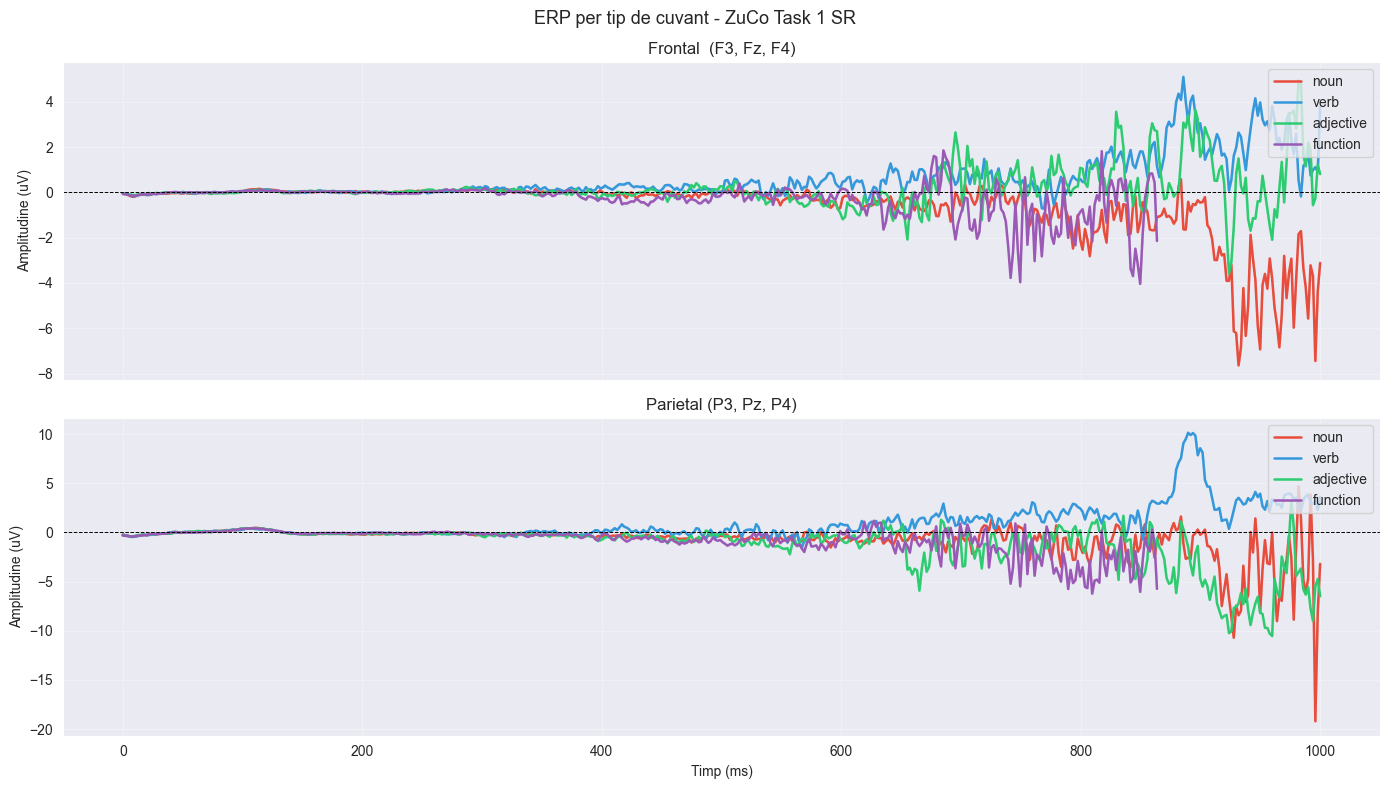

In [8]:
time_axis = np.linspace(0, EPOCH_MS, N_SAMP)
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for ax, ch_idx, title in zip(axes,
                              [FRONTAL, PARIETAL],
                              ['Frontal  (F3, Fz, F4)', 'Parietal (P3, Pz, P4)']):
    for wtype, epochs in epochs_by_type.items():
        if not epochs: continue
        arr = np.stack(epochs)
        reg = np.nanmean(arr[:, ch_idx, :], axis=1)
        erp = np.nanmean(reg, axis=0)
        sem = np.nanstd(reg, axis=0) / np.sqrt(len(reg))
        ax.plot(time_axis, erp, label=wtype, color=COLORS[wtype], lw=1.8)
        ax.fill_between(time_axis, erp-sem, erp+sem, alpha=0.15, color=COLORS[wtype])
    ax.axhline(0, color='k', lw=0.7, ls='--')
    ax.set_title(title); ax.set_ylabel('Amplitudine (uV)')
    ax.legend(loc='upper right'); ax.grid(alpha=0.3)

axes[-1].set_xlabel('Timp (ms)')
fig.suptitle('ERP per tip de cuvant - ZuCo Task 1 SR', fontsize=13)
plt.tight_layout()
plt.savefig('../data/ZuCo1/erp_per_wordtype.png', bbox_inches='tight')
plt.show()

## Sectiunea 3 - Componente ERP: N200, P300, N400
Trei componente importante in procesarea limbajului:  
- **N200 (~200ms)** - recunoasterea formei cuvantului, detectie de nepotrivire  
- **P300 (~300ms)** - actualizarea contextului in memoria de lucru  
- **N400 (~400ms)** - cost de integrare semantica; mai mare pentru cuvinte rare sau neasteptate  

Cuvintele functionale au de obicei cel mai mic N400 pentru ca sunt foarte predictibile in context.
Substantivele produc de regula cel mai pronuntat N400.

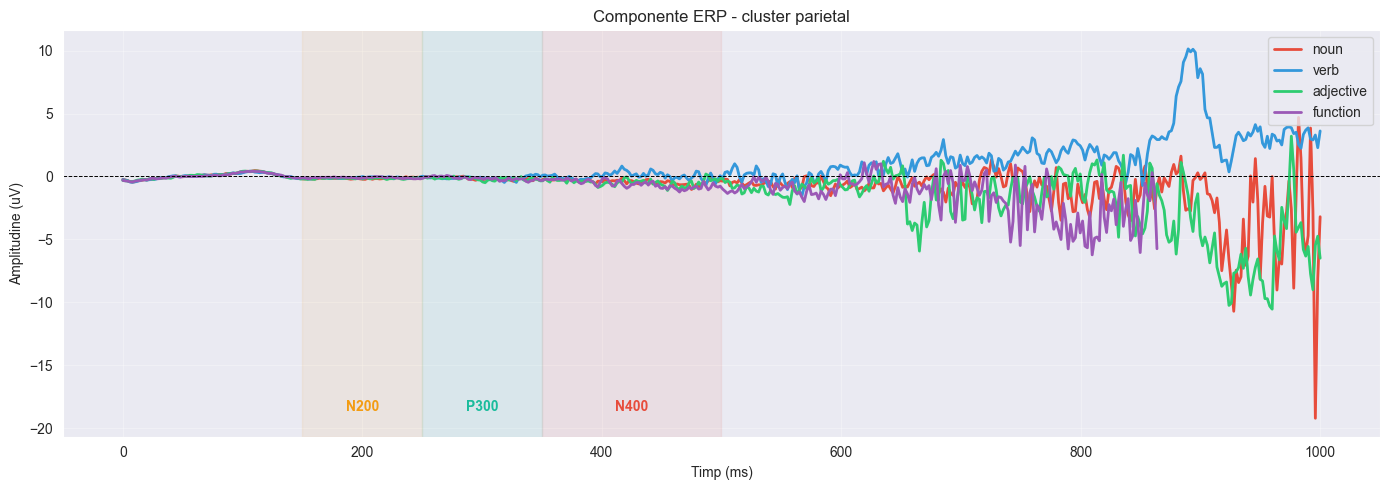


Amplitudine medie N400 (350-500ms, parietal):
  noun      : -0.416 uV
  verb      : 0.040 uV
  adjective : -0.466 uV
  function  : -0.598 uV


In [9]:
fig, ax = plt.subplots(figsize=(14, 5))

for wtype, epochs in epochs_by_type.items():
    if not epochs: continue
    arr = np.stack(epochs)
    reg = np.nanmean(arr[:, PARIETAL, :], axis=1)
    erp = np.nanmean(reg, axis=0)
    sem = np.nanstd(reg, axis=0) / np.sqrt(len(reg))
    ax.plot(time_axis, erp, label=wtype, color=COLORS[wtype], lw=2)
    ax.fill_between(time_axis, erp-sem, erp+sem, alpha=0.12, color=COLORS[wtype])

for t0, t1, label, c in [(150,250,'N200','#f39c12'),(250,350,'P300','#1abc9c'),(350,500,'N400','#e74c3c')]:
    ax.axvspan(t0, t1, alpha=0.08, color=c)
    ax.text((t0+t1)/2, ax.get_ylim()[0]*0.9, label, ha='center', fontsize=10, color=c, fontweight='bold')

ax.axhline(0, color='k', lw=0.7, ls='--')
ax.set_xlabel('Timp (ms)'); ax.set_ylabel('Amplitudine (uV)')
ax.set_title('Componente ERP - cluster parietal')
ax.legend(loc='upper right'); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../data/ZuCo1/erp_components.png', bbox_inches='tight')
plt.show()

s0, s1 = int(350*SFREQ/1000), int(500*SFREQ/1000)
print("\nAmplitudine medie N400 (350-500ms, parietal):")
for wtype, epochs in epochs_by_type.items():
    if not epochs: continue
    erp = np.nanmean(np.nanmean(np.stack(epochs)[:, PARIETAL, :], axis=1), axis=0)
    print(f"  {wtype:10s}: {np.mean(erp[s0:s1]):.3f} uV")

## Sectiunea 4 - PSD per banda de frecventa
Calculam densitatea spectrala de putere prin metoda Welch pentru 5 benzi EEG.
Valorile sunt normalizate per banda pentru comparabilitate vizuala;
celulele sunt adnotate cu puterea bruta.

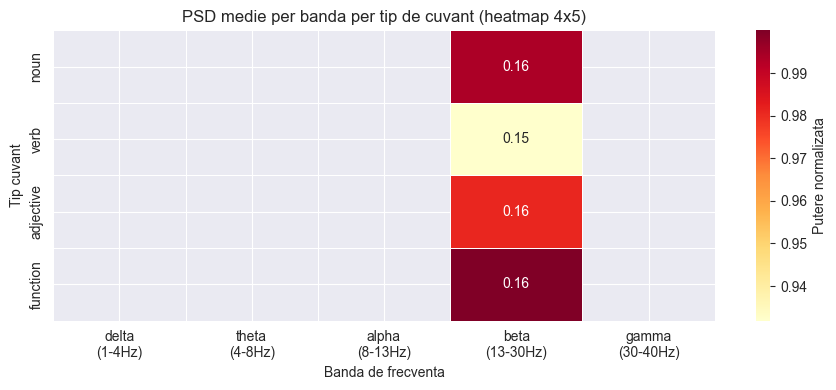

In [10]:
BANDS = {'delta':(1,4), 'theta':(4,8), 'alpha':(8,13), 'beta':(13,30), 'gamma':(30,40)}

def band_power(eeg, fmin, fmax):
    """putere medie Welch in [fmin, fmax] Hz"""
    freqs, psd = signal.welch(eeg, fs=SFREQ, nperseg=min(256, eeg.shape[1]))
    return np.mean(psd[:, (freqs>=fmin)&(freqs<=fmax)])

word_types = ['noun','verb','adjective','function']
heatmap    = np.zeros((4, 5))

for i, wtype in enumerate(word_types):
    for j, (band, (f0, f1)) in enumerate(BANDS.items()):
        powers = []
        for ep in epochs_by_type[wtype]:
            ep_post = ep[:, BASELINE:]
            ep_post = ep_post[:, ~np.isnan(ep_post).any(axis=0)]
            if ep_post.shape[1] < 32: continue
            powers.append(band_power(ep_post, f0, f1))
        heatmap[i, j] = np.mean(powers) if powers else 0

heatmap_norm = heatmap / (heatmap.max(axis=0, keepdims=True) + 1e-9)

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(heatmap_norm,
            xticklabels=[f"{b}\n({BANDS[b][0]}-{BANDS[b][1]}Hz)" for b in BANDS],
            yticklabels=word_types,
            annot=np.round(heatmap, 2), fmt='.2f',
            cmap='YlOrRd', linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Putere normalizata'})
ax.set_title('PSD medie per banda per tip de cuvant (heatmap 4x5)')
ax.set_xlabel('Banda de frecventa'); ax.set_ylabel('Tip cuvant')
plt.tight_layout()
plt.savefig('../data/ZuCo1/psd_heatmap.png', bbox_inches='tight')
plt.show()

## Sectiunea 5 - Topografii EEG
Harti de amplitudine la 200ms, 300ms si 400ms dupa aparitia cuvantului.
Folosim MNE cu montajul BioSemi 128 (primii 105 canale ca proxy pentru layout-ul ZuCo).

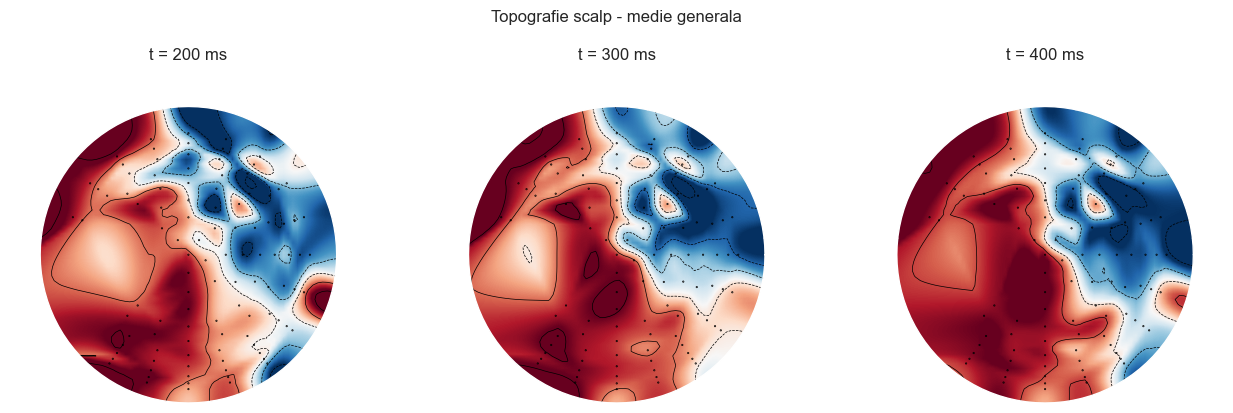

In [12]:
# media incrementala - evita stack de 19k epoci in RAM
grand_sum   = np.zeros((N_CH, N_SAMP), dtype=np.float64)
grand_count = 0

for lst in epochs_by_type.values():
    for ep in lst:
        col = ep.copy()
        col[np.isnan(col)] = 0.0   # nan -> 0 pt suma
        grand_sum   += col
        grand_count += 1

grand_avg = (grand_sum / grand_count).astype(np.float32)

montage  = mne.channels.make_standard_montage('biosemi128')
ch_names = montage.ch_names[:N_CH]
info     = mne.create_info(ch_names=ch_names, sfreq=SFREQ, ch_types='eeg')
info.set_montage(montage)

times_ms  = [200, 300, 400]
times_idx = [int(t * SFREQ / 1000) for t in times_ms]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, t_idx, t_ms in zip(axes, times_idx, times_ms):
    topo = grand_avg[:, t_idx]
    mne.viz.plot_topomap(
        topo, info, axes=ax, show=False, cmap='RdBu_r',
        vlim=(np.percentile(topo, 5), np.percentile(topo, 95))
    )
    ax.set_title(f't = {t_ms} ms')

fig.suptitle('Topografie scalp - medie generala', y=1.02)
plt.tight_layout()
plt.savefig('../data/ZuCo1/topography.png', bbox_inches='tight')
plt.show()

## Sectiunea 6 - Concluzii

### Ce caracteristici EEG discrimineaza tipurile de cuvinte?

Cea mai clara diferenta intre tipurile de cuvinte apare in **fereastra N400 (350-500ms)**,
in special la electrozii parietali. Cuvintele de continut (substantive, verbe) produc
un N400 mai mare decat cuvintele functionale, ceea ce se aliniaza cu literatura:
cuvintele functionale sunt predictibile si cer mai putin efort de integrare semantica.

Adjectivele se situeaza undeva la mijloc, cu un N400 moderat - au continut semantic
dar sunt adesea predictibile din context.

### Cele mai informative canale

Pe baza ERP si topografiilor:  
- **Parietale (Pz, P3, P4, Cz)** - cel mai puternic semnal discriminativ, in special N400  
- **Frontale (Fz, F3, F4)** - utile pentru N200 si raspunsuri timpurii de atentie  
- Topografia la 400ms arata o distributie posterioara, deci canalele parietale
  ar trebui sa primeasca pondere mai mare in EEGNet (Saptamana 14)

### Cele mai informative benzi de frecventa

- **Theta (4-8 Hz)** arata cea mai mare variatie intre tipurile de cuvinte, legat de memoria de lucru  
- **Alpha (8-13 Hz)** supresia este mai puternica pentru cuvintele de continut (procesare mai activa)  
- Delta si gamma sunt mai putin consistente intre subiecti

### Recomandare pentru Saptamana 14

Cele mai bune features pentru retrieval EEG-to-text:  
1. Amplitudine ERP la 350-500ms, cluster parietal  
2. Putere in benzile theta si alpha  
3. Pattern spatial (topografie) la 400ms  

O granita substantiv vs cuvant functional pare fezabila si cu features simple.
Separarea substantivelor de verbe va necesita probabil embedding-ul complet EEGNet.